# Feature Importance — Production Ensemble Model
Loads `models/production_model.joblib` (EnsembleGoalModel: 0.8 LGBM + 0.2 XGB),
extracts importances from each sub-model, and visualises them.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from joblib import load

from src.features.feature_columns import FEATURE_COLS

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load production model
model = load('../models/production_model.joblib')
print(type(model))
print(f'Sub-models: {[type(m).__name__ for m in model.models]}')
print(f'Weights:    {model.weights}')
print(f'Features:   {len(FEATURE_COLS)}')

<class 'src.models.ensemble.EnsembleGoalModel'>
Sub-models: ['LGBMGoalModel', 'XGBGoalModel']
Weights:    [0.8, 0.2]
Features:   21


c:\Users\yuval\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:27:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [3]:
# --- Extract importances from each sub-model ---

lgbm_model = model.models[0]   # LGBMGoalModel
xgb_model  = model.models[1]   # XGBGoalModel

# LGBM: gain importance (how much each split improves the loss)
lgbm_imp_home = lgbm_model.home_model.booster_.feature_importance(importance_type='gain')
lgbm_imp_away = lgbm_model.away_model.booster_.feature_importance(importance_type='gain')
lgbm_gain = (lgbm_imp_home + lgbm_imp_away) / 2

lgbm_split_home = lgbm_model.home_model.booster_.feature_importance(importance_type='split')
lgbm_split_away = lgbm_model.away_model.booster_.feature_importance(importance_type='split')
lgbm_split = (lgbm_split_home + lgbm_split_away) / 2

# XGBoost: gain importance
xgb_imp_home = xgb_model.home_model.feature_importances_
xgb_imp_away = xgb_model.away_model.feature_importances_
xgb_gain = (xgb_imp_home + xgb_imp_away) / 2

# Ensemble: weighted average of normalised importances
lgbm_norm = lgbm_gain / lgbm_gain.sum()
xgb_norm  = xgb_gain  / xgb_gain.sum()
ensemble_norm = 0.8 * lgbm_norm + 0.2 * xgb_norm

df_imp = pd.DataFrame({
    'feature':       FEATURE_COLS,
    'lgbm_gain':     lgbm_gain,
    'lgbm_gain_pct': lgbm_norm * 100,
    'lgbm_split':    lgbm_split,
    'xgb_gain':      xgb_gain,
    'xgb_gain_pct':  xgb_norm * 100,
    'ensemble_pct':  ensemble_norm * 100,
}).sort_values('ensemble_pct', ascending=False).reset_index(drop=True)

df_imp.round(2)

,feature,lgbm_gain,lgbm_gain_pct,lgbm_split,xgb_gain,xgb_gain_pct,ensemble_pct
0,rank_diff,55178.03,56.40,1208.5,0.35,35.349998,52.19
1,elo_diff,16298.97,16.66,1054.5,0.11,10.640000,15.46
2,rating_a_before,5282.96,5.40,716.5,0.05,4.940000,5.31
3,rating_b_before,4965.34,5.08,679.5,0.05,5.240000,5.11
4,weighted_goals_against_diff_last5,1744.62,1.78,355.5,0.03,3.220000,2.07
5,team_b_matches_played_before,1629.53,1.67,414.5,0.03,2.780000,1.89
6,team_a_matches_played_before,1329.62,1.36,374.5,0.03,2.640000,1.61
7,opponent_strength_diff_last5,1330.82,1.36,385.0,0.03,2.550000,1.60
8,log_market_value_a,1214.94,1.24,319.5,0.03,2.860000,1.57
9,avg_player_value_diff,1027.85,1.05,265.5,0.03,2.730000,1.39


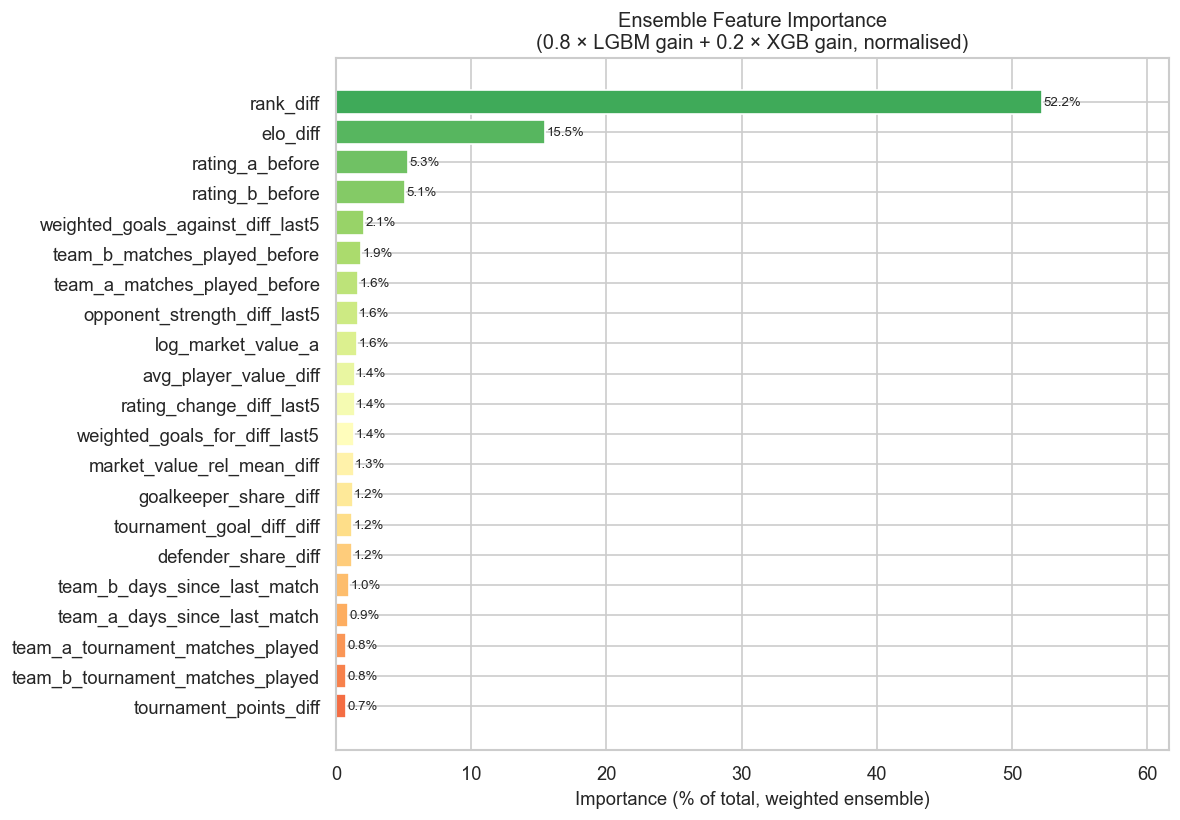

In [4]:
# --- Plot 1: Ensemble weighted importance (top 21 features) ---
fig, ax = plt.subplots(figsize=(10, 7))

colors = cm.RdYlGn(np.linspace(0.85, 0.2, len(df_imp)))
bars = ax.barh(df_imp['feature'][::-1], df_imp['ensemble_pct'][::-1], color=colors[::-1])

for bar, val in zip(bars, df_imp['ensemble_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Importance (% of total, weighted ensemble)', fontsize=11)
ax.set_title('Ensemble Feature Importance\n(0.8 × LGBM gain + 0.2 × XGB gain, normalised)', fontsize=12)
ax.set_xlim(0, df_imp['ensemble_pct'].max() * 1.18)
plt.tight_layout()
plt.show()

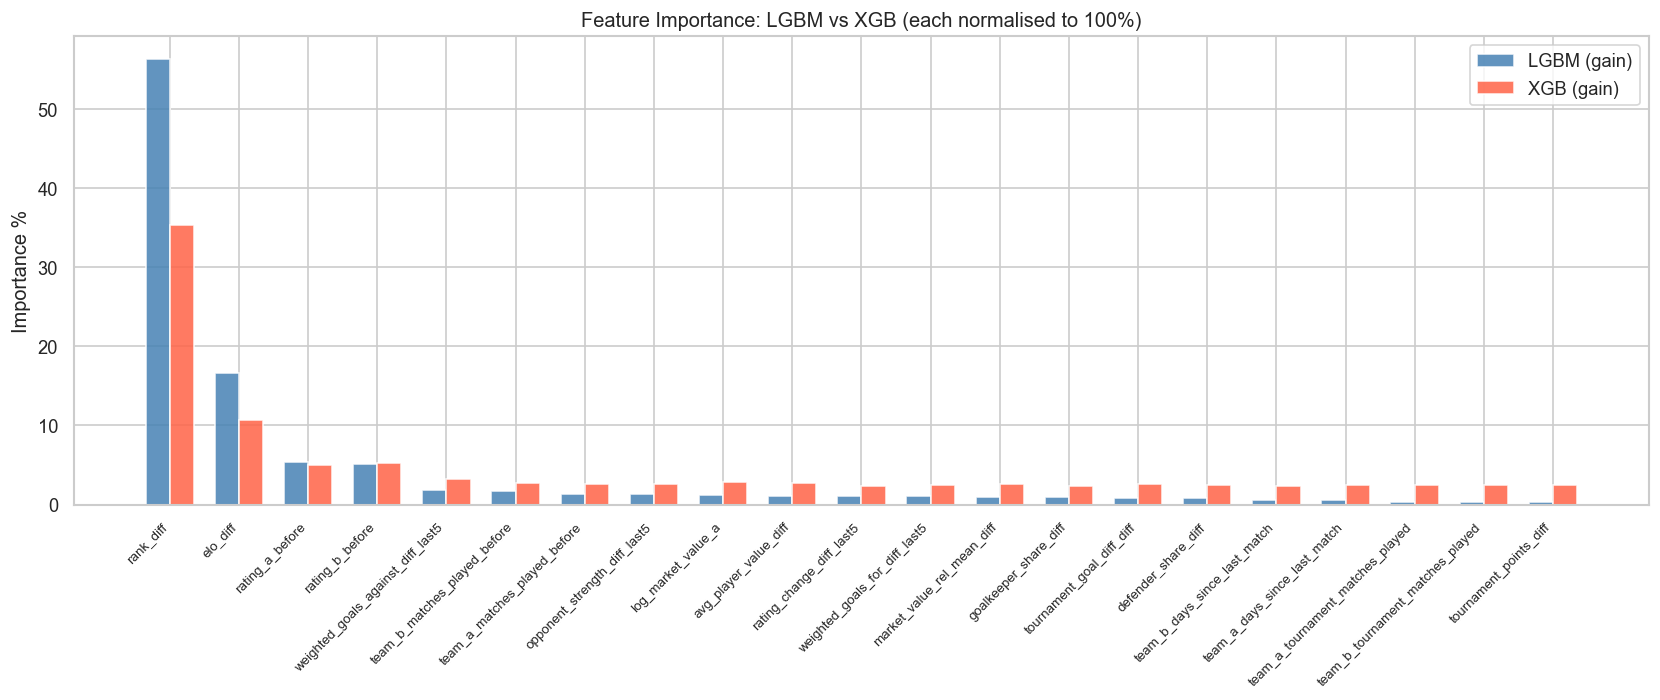

In [5]:
# --- Plot 2: LGBM vs XGB side-by-side (normalised %) ---
df_sorted = df_imp.sort_values('ensemble_pct', ascending=False)

x = np.arange(len(FEATURE_COLS))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, df_sorted['lgbm_gain_pct'], w, label='LGBM (gain)', color='steelblue', alpha=0.85)
ax.bar(x + w/2, df_sorted['xgb_gain_pct'],  w, label='XGB (gain)',  color='tomato',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importance %')
ax.set_title('Feature Importance: LGBM vs XGB (each normalised to 100%)')
ax.legend()
plt.tight_layout()
plt.show()

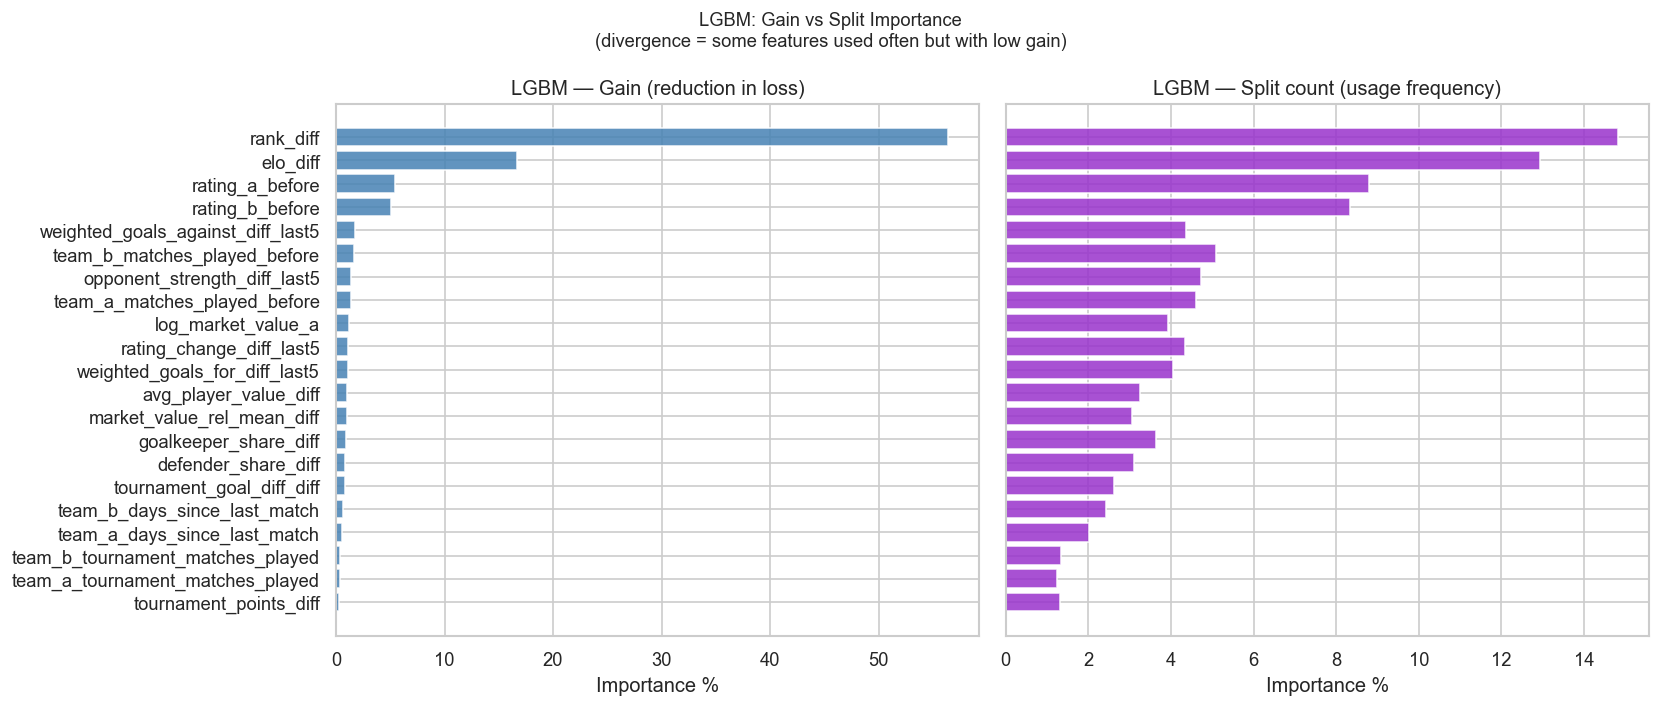

In [6]:
# --- Plot 3: LGBM gain vs split (are the same features used in many trees?) ---
df_lgbm = df_imp[['feature', 'lgbm_gain_pct', 'lgbm_split']].copy()
df_lgbm['lgbm_split_pct'] = df_lgbm['lgbm_split'] / df_lgbm['lgbm_split'].sum() * 100
df_lgbm = df_lgbm.sort_values('lgbm_gain_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].barh(df_lgbm['feature'][::-1], df_lgbm['lgbm_gain_pct'][::-1], color='steelblue', alpha=0.85)
axes[0].set_title('LGBM — Gain (reduction in loss)')
axes[0].set_xlabel('Importance %')

axes[1].barh(df_lgbm['feature'][::-1], df_lgbm['lgbm_split_pct'][::-1], color='darkorchid', alpha=0.85)
axes[1].set_title('LGBM — Split count (usage frequency)')
axes[1].set_xlabel('Importance %')

plt.suptitle('LGBM: Gain vs Split Importance\n(divergence = some features used often but with low gain)', fontsize=11)
plt.tight_layout()
plt.show()

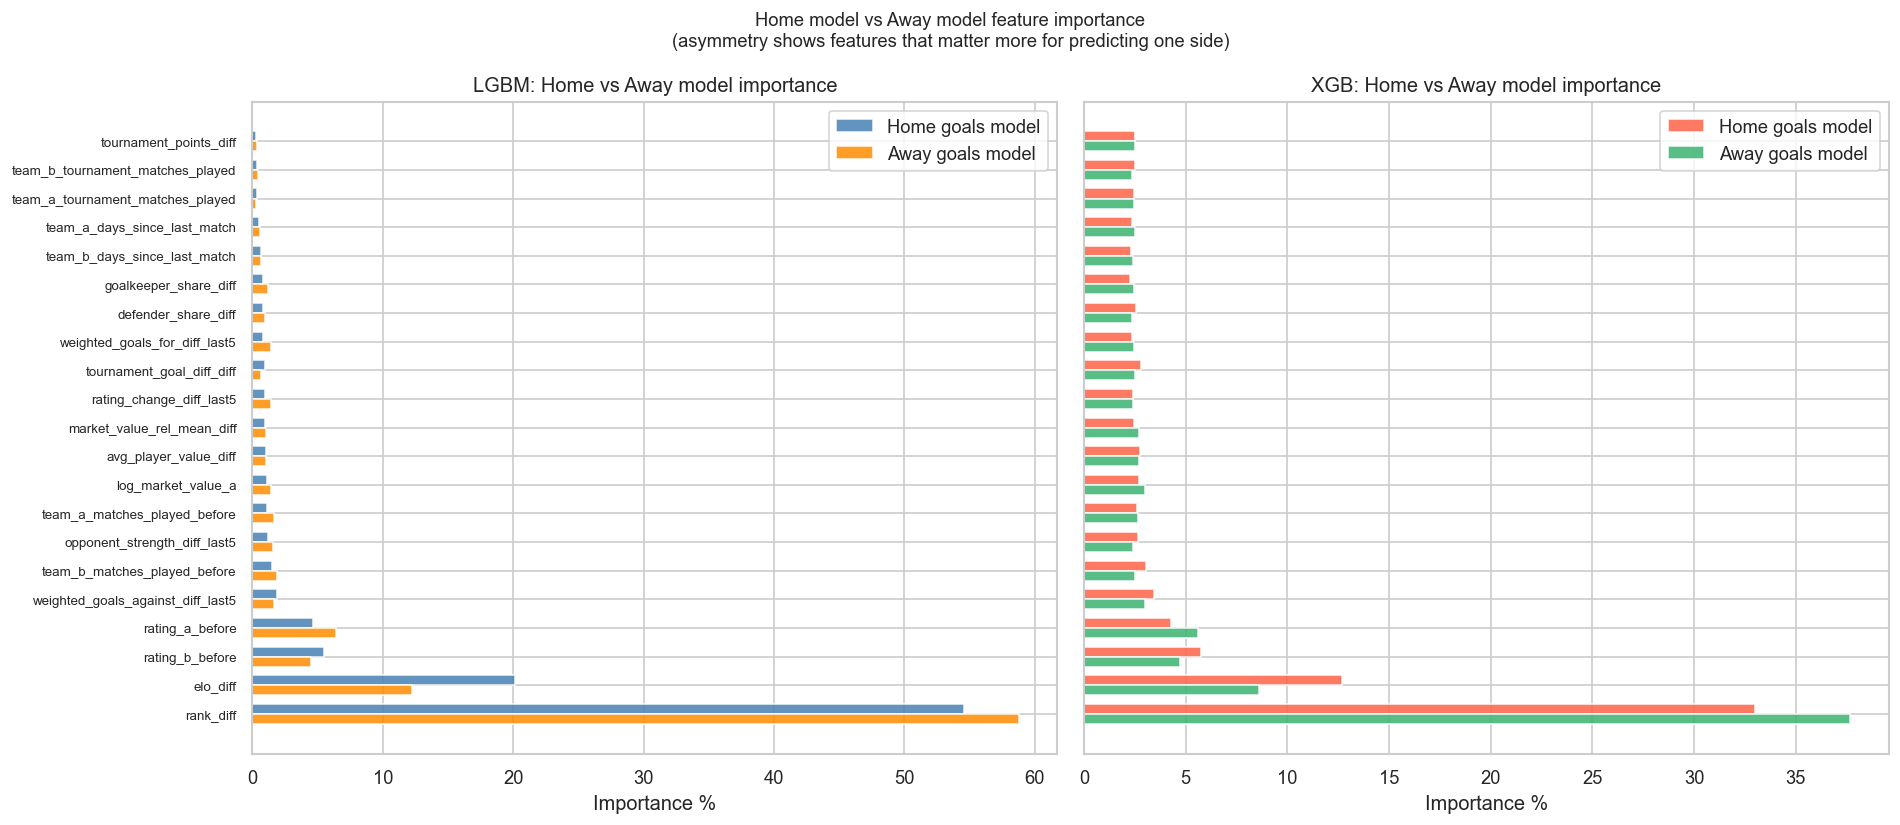

In [7]:
# --- Plot 4: LGBM SHAP-style — home model vs away model importance ---
df_home_away = pd.DataFrame({
    'feature':        FEATURE_COLS,
    'lgbm_home_%':    lgbm_imp_home / lgbm_imp_home.sum() * 100,
    'lgbm_away_%':    lgbm_imp_away / lgbm_imp_away.sum() * 100,
    'xgb_home_%':     xgb_imp_home / xgb_imp_home.sum() * 100,
    'xgb_away_%':     xgb_imp_away / xgb_imp_away.sum() * 100,
}).sort_values('lgbm_home_%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

x = np.arange(len(FEATURE_COLS))
w = 0.35

axes[0].barh(x + w/2, df_home_away['lgbm_home_%'], w, label='Home goals model', color='steelblue', alpha=0.85)
axes[0].barh(x - w/2, df_home_away['lgbm_away_%'], w, label='Away goals model', color='darkorange', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(df_home_away['feature'], fontsize=8)
axes[0].set_title('LGBM: Home vs Away model importance')
axes[0].set_xlabel('Importance %')
axes[0].legend()

axes[1].barh(x + w/2, df_home_away['xgb_home_%'], w, label='Home goals model', color='tomato', alpha=0.85)
axes[1].barh(x - w/2, df_home_away['xgb_away_%'], w, label='Away goals model', color='mediumseagreen', alpha=0.85)
axes[1].set_title('XGB: Home vs Away model importance')
axes[1].set_xlabel('Importance %')
axes[1].legend()

plt.suptitle('Home model vs Away model feature importance\n(asymmetry shows features that matter more for predicting one side)', fontsize=11)
plt.tight_layout()
plt.show()

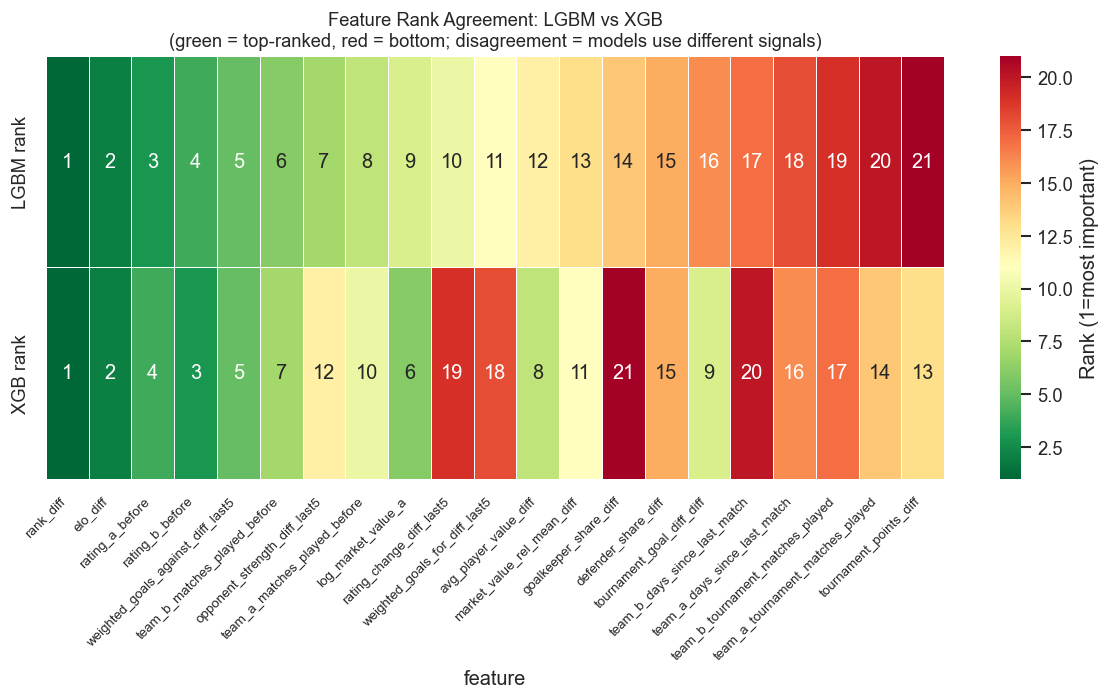


Largest rank disagreements between LGBM and XGB:
                                  LGBM rank  XGB rank  rank_diff
feature                                                         
rating_change_diff_last5               10.0      19.0        9.0
tournament_points_diff                 21.0      13.0        8.0
tournament_goal_diff_diff              16.0       9.0        7.0
goalkeeper_share_diff                  14.0      21.0        7.0
weighted_goals_for_diff_last5          11.0      18.0        7.0
team_a_tournament_matches_played       20.0      14.0        6.0
opponent_strength_diff_last5            7.0      12.0        5.0
avg_player_value_diff                  12.0       8.0        4.0


In [8]:
# --- Plot 5: Agreement heatmap — how consistently LGBM and XGB rank features ---
rank_lgbm = df_imp.set_index('feature')['lgbm_gain_pct'].rank(ascending=False)
rank_xgb  = df_imp.set_index('feature')['xgb_gain_pct'].rank(ascending=False)

rank_df = pd.DataFrame({'LGBM rank': rank_lgbm, 'XGB rank': rank_xgb})
rank_df['rank_diff'] = (rank_df['LGBM rank'] - rank_df['XGB rank']).abs()
rank_df = rank_df.sort_values('LGBM rank')

fig, ax = plt.subplots(figsize=(10, 6))
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(
    rank_df[['LGBM rank', 'XGB rank']].T,
    annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1=most important)'}
)
ax.set_title('Feature Rank Agreement: LGBM vs XGB\n(green = top-ranked, red = bottom; disagreement = models use different signals)', fontsize=11)
ax.set_xticklabels(rank_df.index, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('\nLargest rank disagreements between LGBM and XGB:')
print(rank_df.sort_values('rank_diff', ascending=False).head(8).to_string())

In [9]:
# --- Summary table ---
summary = df_imp[['feature', 'lgbm_gain_pct', 'xgb_gain_pct', 'ensemble_pct']].copy()
summary.columns = ['Feature', 'LGBM %', 'XGB %', 'Ensemble %']

# Flag features where the two models strongly disagree (> 2x ratio)
summary['Agreement'] = summary.apply(
    lambda r: 'agree' if abs(r['LGBM %'] - r['XGB %']) < 3 else
              ('LGBM>>XGB' if r['LGBM %'] > r['XGB %'] else 'XGB>>LGBM'),
    axis=1
)

print(summary.to_string(index=False))

                          Feature    LGBM %     XGB %  Ensemble % Agreement
                        rank_diff 56.398567 35.349102   52.188674 LGBM>>XGB
                         elo_diff 16.659507 10.638664   15.455339 LGBM>>XGB
                  rating_a_before  5.399820  4.943278    5.308512     agree
                  rating_b_before  5.075173  5.236540    5.107446     agree
weighted_goals_against_diff_last5  1.783213  3.222736    2.071117     agree
     team_b_matches_played_before  1.665580  2.780320    1.888528     agree
     team_a_matches_played_before  1.359032  2.637753    1.614776     agree
     opponent_strength_diff_last5  1.360259  2.546767    1.597561     agree
               log_market_value_a  1.241818  2.862740    1.566003     agree
            avg_player_value_diff  1.050586  2.733895    1.387248     agree
         rating_change_diff_last5  1.132604  2.401326    1.386348     agree
    weighted_goals_for_diff_last5  1.087789  2.410086    1.352249     agree
       marke